## Set up

**Task:** Explore the Iris dataset and train a simple model using MLflow

In [2]:
import matplotlib.pyplot as plt
import mlflow
import mpl_toolkits.mplot3d
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# MLflow config
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('MLflow quickstart')

<Experiment: artifact_location='/home/cyancy/Projects/demo_MLflow/mlruns/1', creation_time=1788669016705, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1788669016705, lifecycle_stage='active', name='MLflow quickstart', tags={}, trace_location=None, workspace='default'>

## Data import and organization

In [10]:
X, y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

classes: list[str] = ['setosa', 'versicolor', 'virginica']

### Data exploration

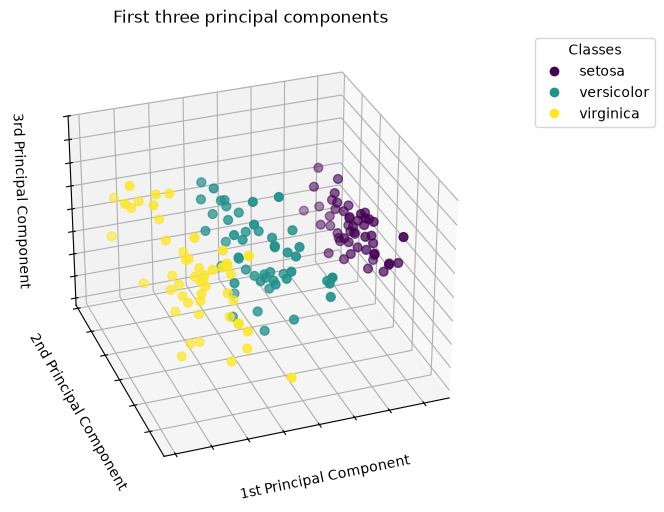

In [22]:
fig: plt.Figure = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

X_reduced = PCA(n_components=3).fit_transform(X, y)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    X_reduced[:, 2],
    c=y,
    s=40
)

ax.set(
    title='First three principal components',
    xlabel='1st Principal Component',
    ylabel='2nd Principal Component',
    zlabel='3rd Principal Component',
)
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

legend  = ax.legend(
    scatter.legend_elements()[0],
    classes,
    bbox_to_anchor=(1.1, 1),
    loc='upper left',
    title='Classes'
)

ax.view_init(azim=110, elev=-150)
plt.show()

## Training with MLflow

In [23]:
params = {
    'solver': 'lbfgs',
    'max_iter': 100,
    'random_state': 8888,
}

#### Autologging

In [24]:
mlflow.sklearn.autolog()

lr = LogisticRegression(**params)
lr.fit(X_train, y_train)

2026/09/06 13:39:22 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'ba23190e33204e539b7daac18227d90d', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current sklearn workflow
2026/09/06 13:39:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/cyancy/miniforge3/envs/demo_torchflow/lib/python3.14/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",8888
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

#### Manual logging

In [26]:
with mlflow.start_run():
    mlflow.log_params(params)

    lr= LogisticRegression(**params)
    lr.fit(X_train, y_train)

    model_info = mlflow.sklearn.log_model(sk_model=lr, name='iris_model')
    
    y_pred = lr.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    mlflow.log_metric('accuracy', accuracy)

    mlflow.set_tag("Training Info", "Basic LR model for iris data")

2026/09/06 13:57:13 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
/home/cyancy/miniforge3/envs/demo_torchflow/lib/python3.14/site-packages/sklearn/metrics/_classification.py:3424: FutureWarning: `y_pred` was renamed to `y_proba` in version 1.9 and will be removed in 1.11. Use `y_proba` instead.
  warnings.warn(


## Inference

In [32]:
loaded_model = mlflow.sklearn.load_model(model_info.model_uri)


preds = loaded_model.predict(X_test)
iris_feature_names  = datasets.load_iris().feature_names

result =  pd.DataFrame(X_test, columns=iris_feature_names)
result['actual class'] = y_test
result['predicted_class'] = preds

result.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),actual class,predicted_class
0,6.1,2.8,4.7,1.2,1,1
1,5.7,3.8,1.7,0.3,0,0
2,7.7,2.6,6.9,2.3,2,2
3,6.0,2.9,4.5,1.5,1,1
4,6.8,2.8,4.8,1.4,1,1
5,5.4,3.4,1.5,0.4,0,0
6,5.6,2.9,3.6,1.3,1,1
7,6.9,3.1,5.1,2.3,2,2
8,6.2,2.2,4.5,1.5,1,1
9,5.8,2.7,3.9,1.2,1,1
